In [ ]:
!pip install stable-baselines3[extra] yfinance -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 12.4 MB/s eta 0:00:00


In [ ]:
%%writefile trading_env.py
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class TradingEnv(gym.Env):
    def __init__(self, prices, window_size=20, initial_balance=10_000.0):
        super().__init__()
        self.prices = np.array(prices).flatten().astype(np.float32)
        self.window_size = window_size
        self.initial_balance = float(initial_balance)
        self._returns = np.diff(self.prices) / (self.prices[:-1] + 1e-8)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(window_size+2,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)
        self.reset()

    def _get_obs(self):
        ret_window = self._returns[self.current_step-self.window_size:self.current_step]
        return np.concatenate([ret_window,
            [float(self.shares_held > 0),
             self.cash_balance / self.initial_balance]]).astype(np.float32)

    def _portfolio_value(self):
        return self.cash_balance + self.shares_held * float(self.prices[self.current_step])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.cash_balance = self.initial_balance
        self.shares_held = 0
        self.prev_portfolio_value = self.initial_balance
        self.trade_log = []
        return self._get_obs(), {}

    def step(self, action):
        price = float(self.prices[self.current_step])
        if action == 1 and self.cash_balance >= price:
            shares = int(self.cash_balance // price)
            self.shares_held += shares
            self.cash_balance -= shares * price
            self.trade_log.append({"step": self.current_step, "action": "BUY", "price": price})
        elif action == 2 and self.shares_held > 0:
            self.cash_balance += self.shares_held * price
            self.trade_log.append({"step": self.current_step, "action": "SELL", "price": price})
            self.shares_held = 0
        pv = self._portfolio_value()
        reward = (pv - self.prev_portfolio_value) / (self.prev_portfolio_value + 1e-8) * 100.0
        self.prev_portfolio_value = pv
        self.current_step += 1
        terminated = self.current_step >= len(self.prices) - 1
        return self._get_obs(), float(reward), terminated, False, {"portfolio_value": pv}

Overwriting trading_env.py


In [ ]:
import yfinance as yf
import numpy as np
from trading_env import TradingEnv
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

# 데이터
df = yf.download('AAPL', start='2020-01-01', end='2023-01-01', auto_adjust=True)
prices_train = df['Close'].values.flatten().astype('float32')

df_test = yf.download('AAPL', start='2023-01-01', end='2024-01-01', auto_adjust=True)
prices_test = df_test['Close'].values.flatten().astype('float32')

# 학습
env_fn = lambda: TradingEnv(prices_train)
vec_env = DummyVecEnv([lambda: Monitor(env_fn())])

model = PPO("MlpPolicy", vec_env,
            learning_rate=3e-4, n_steps=2048,
            batch_size=64, n_epochs=10,
            ent_coef=0.05, verbose=1)
model.learn(total_timesteps=200_000)
model.save("ppo_trading")
print("학습 완료")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.da

Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 735      |
|    ep_rew_mean     | 24.6     |
| time/              |          |
|    fps             | 566      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 735         |
|    ep_rew_mean          | 32.2        |
| time/                   |             |
|    fps                  | 487         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010539495 |
|    clip_fraction        | 0.0375      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.00455    |
|    learning_rate        | 0.

테스트 수익률: +39.10%  |  최종 포트폴리오: $13,909.51
행동 분포 — HOLD: 156, BUY: 35, SELL: 38


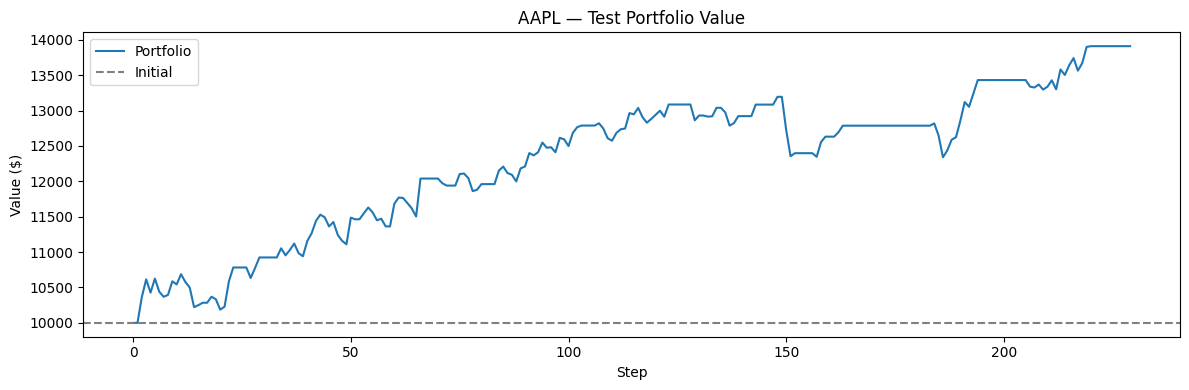

In [ ]:
import matplotlib.pyplot as plt

env_test = TradingEnv(prices_test)
obs, _ = env_test.reset()
done = False
portfolio_values = [10_000]
actions_taken = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env_test.step(int(action))
    portfolio_values.append(info['portfolio_value'])
    actions_taken.append(int(action))

final = portfolio_values[-1]
ret = (final - 10_000) / 10_000 * 100
print(f"테스트 수익률: {ret:+.2f}%  |  최종 포트폴리오: ${final:,.2f}")

action_counts = {0: actions_taken.count(0), 1: actions_taken.count(1), 2: actions_taken.count(2)}
print(f"행동 분포 — HOLD: {action_counts[0]}, BUY: {action_counts[1]}, SELL: {action_counts[2]}")

# 포트폴리오 가치 그래프
plt.figure(figsize=(12,4))
plt.plot(portfolio_values, label='Portfolio')
plt.axhline(10_000, linestyle='--', color='gray', label='Initial')
plt.title('AAPL — Test Portfolio Value')
plt.xlabel('Step')
plt.ylabel('Value ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Buy-and-Hold 벤치마크 비교
bh_shares = int(10_000 // prices_test[0])
bh_final = bh_shares * prices_test[-1] + (10_000 - bh_shares * prices_test[0])
bh_ret = (bh_final - 10_000) / 10_000 * 100

print(f"PPO 에이전트:    {ret:+.2f}%  (${final:,.2f})")
print(f"Buy-and-Hold:   {bh_ret:+.2f}%  (${bh_final:,.2f})")
print(f"초과 수익(알파):  {ret - bh_ret:+.2f}%p")

PPO 에이전트:    +39.10%  ($13,909.51)
Buy-and-Hold:   +54.59%  ($15,458.78)
초과 수익(알파):  -15.49%p
